# Lateral–Torsional Buckling — simply-supported I-beam, midspan point load

Same I-section and same imperfection-retrofit workflow as the
companion `example_LTB_uniform_moment.ipynb`, but the loading is a
**transverse point force at midspan** instead of end moments. The
moment distribution is now triangular — `M(x) = P·x/2` on the left
half, `P·(L-x)/2` on the right half, with a peak `M_max = PL/4` at
the loaded section.

Moment gradients *stabilise* LTB: only a fraction of the span sees
near-maximum moment, so the critical maximum moment for a
concentrated midspan load is higher than it is for a uniform moment
of the same magnitude. The classical correction is the AISC
**moment-gradient factor** `Cb`:

$$
M_{\mathrm{cr}}^{\text{mid-load}} \;=\; C_b \cdot
\frac{\pi}{L_b}\,\sqrt{E\,I_{\text{weak}} \; G\,J}
$$

For a simply-supported beam with a concentrated midspan load,
`Cb ≈ 1.365` (AISC 12.5-formula). So the critical moment is about
37 % higher than the uniform-moment case, and the critical *load*
is `P_cr = 4·M_cr/L_b`.

Everything else in the notebook — the section, the half-sine
imperfection retrofit, the 3-D corotational `elasticBeamColumn`
build, the sweep, the twist extraction — is identical to the
uniform-moment notebook. This one differs only in how the bending
moment is applied.

In [1]:
from apeGmsh import apeGmsh, Results
import numpy as np
import matplotlib.pyplot as plt

# ---- Steel material ----------------------------------------------
E   = 200_000.0
nu  = 0.3
G   = E / (2.0 * (1 + nu))

# ---- W-section geometry [mm] -------------------------------------
bf      = 150.0
tf      = 12.0
h_total = 300.0
tw      = 8.0
h_web   = h_total - 2 * tf

A = 2 * bf * tf + h_web * tw
I_strong = (2 * (bf * tf ** 3 / 12.0
                 + bf * tf * ((h_web + tf) / 2.0) ** 2)
            + tw * h_web ** 3 / 12.0)
I_weak = 2 * (tf * bf ** 3 / 12.0) + h_web * tw ** 3 / 12.0
J = (2 * bf * tf ** 3 + h_web * tw ** 3) / 3.0

# ---- Beam geometry -----------------------------------------------
L  = 6000.0
lc = 150.0
delta_0 = L / 1000.0

# ---- LTB reference numbers ---------------------------------------
# Uniform-moment case (Cb = 1):
M_cr_uniform = (np.pi / L) * np.sqrt(E * I_weak * G * J)
# Concentrated midspan load case (Cb ≈ 1.365 per AISC):
C_b = 1.365
M_cr_mid = C_b * M_cr_uniform
# Critical point-load magnitude:  M_max = P L / 4  →  P_cr = 4 M_cr / L
P_cr = 4.0 * M_cr_mid / L

print(f'Section W{h_total:.0f}x{int(bf)}x{int(tf)}  (A={A:.0f} mm^2)')
print(f'  I_strong = {I_strong:.3e} mm^4    '
      f'I_weak = {I_weak:.3e} mm^4   J = {J:.0f} mm^4')
print()
print(f'Unbraced length L_b = {L:.0f} mm, imperfection L/1000 = {delta_0:.2f} mm')
print(f'M_cr uniform (Cb=1.0)  = {M_cr_uniform/1e6:.2f} kN*m')
print(f'M_cr midspan load (Cb = {C_b}) = {M_cr_mid/1e6:.2f} kN*m')
print(f'P_cr (midspan load)    = {P_cr/1e3:.2f} kN')

Section W300x150x12  (A=5808 mm^2)
  I_strong = 8.871e+07 mm^4    I_weak = 6.762e+06 mm^4   J = 219904 mm^4

Unbraced length L_b = 6000 mm, imperfection L/1000 = 6.00 mm
M_cr uniform (Cb=1.0)  = 79.19 kN*m
M_cr midspan load (Cb = 1.365) = 108.10 kN*m
P_cr (midspan load)    = 72.07 kN


## 1. Build the beam + retrofit lateral imperfection

Identical to the uniform-moment notebook: one straight `add_line`
call, then `replace_line` with `shape='sine'`, `n_segments=16`, and
`direction=(0, 1, 0)` (weak-axis lateral).

In [2]:
m = apeGmsh(model_name='LTB_midspan', verbose=False)
m.begin()

p_pin  = m.model.geometry.add_point(0, 0, 0, lc=lc, label='pin')
p_roll = m.model.geometry.add_point(L, 0, 0, lc=lc, label='roller')

beam = m.model.geometry.add_line(p_pin, p_roll, label='beam')
m.physical.add_curve(tags=[beam], name='pg_beam')

seg_tags = m.model.geometry.replace_line(
    beam,
    magnitude=delta_0,
    direction=(0, 1, 0),
    shape='sine',
    n_segments=16,
)
print(f'beam replaced with {len(seg_tags)} sine segments')

m.mesh.sizing.set_global_size(lc)
m.mesh.generation.generate(dim=1)

fem = m.mesh.queries.get_fem_data(remove_orphans=True)
m.end()

print(f'nodes: {len(fem.nodes.ids)}')
for g in fem.elements:
    print(f'  {g.type_name:6s} n={len(g)}')

beam replaced with 16 sine segments
nodes: 49
  line2  n=48
  point1 n=17


## 2. OpenSees 3-D model

Same boundary conditions (fork supports, pin + roller) and the same
corotational 3-D build as the uniform-moment notebook. The only
wrinkle is that we need to identify the **midspan mesh node** to
apply the transverse point load there. Because we used
`n_segments=16` with a sine imperfection, one of the interior nodes
sits exactly at `s = 1/2` along the beam — that's our loaded node.

In [3]:
import openseespy.opensees as ops

ops.wipe()
ops.model('basic', '-ndm', 3, '-ndf', 6)
ops.timeSeries('Linear', 1)

for nid, xyz in fem.nodes.get():
    ops.node(int(nid), float(xyz[0]), float(xyz[1]), float(xyz[2]))

pin_id  = int(fem.nodes.get_ids(target='pin')[0])
roll_id = int(fem.nodes.get_ids(target='roller')[0])
ops.fix(pin_id,  1, 1, 1,  1, 0, 0)
ops.fix(roll_id, 0, 1, 1,  1, 0, 0)

ops.geomTransf('Corotational', 1, 0, 0, 1)

n_elem = 0
for group in fem.elements.get(element_type='line2'):
    for eid, conn in group:
        ops.element(
            'elasticBeamColumn', int(eid),
            int(conn[0]), int(conn[1]),
            A, E, G, J, I_strong, I_weak, 1,
        )
        n_elem += 1
print(f'elasticBeamColumn elements: {n_elem}')

# --- Locate midspan node for load application --------------------
beam_ids    = np.array(
    [int(n) for n in fem.nodes.get_ids(target='pg_beam')])
beam_coords = fem.nodes.get_coords(target='pg_beam')
order       = np.argsort(beam_coords[:, 0])
beam_ids    = beam_ids[order]
beam_coords = beam_coords[order]
xs          = beam_coords[:, 0]
mid_idx     = int(np.argmin(np.abs(xs - L / 2.0)))
mid_nid     = int(beam_ids[mid_idx])
print(f'midspan node id = {mid_nid} at x = {xs[mid_idx]:.1f} mm')

elasticBeamColumn elements: 48
midspan node id = 10 at x = 3000.0 mm


## 3. Apply `-Pz` at midspan and sweep

The reference load is a unit downward force on the midspan node.
The integrator advances the load factor so the applied force is
`−(step+1)·dP` in global Z. We ramp to ~0.95·P_cr in 50 load-control
steps.

In [4]:
ops.pattern('Plain', 1, 1)
ops.load(mid_nid, 0, 0, -1.0, 0, 0, 0)     # -1 N in global Z at midspan

ops.constraints('Transformation')
ops.numberer('RCM')
ops.system('UmfPack')
ops.test('NormDispIncr', 1.0e-7, 200)
ops.algorithm('Newton')

P_target = 0.95 * P_cr
n_steps  = 50
dP       = P_target / n_steps
ops.integrator('LoadControl', dP)
ops.analysis('Static')

hist_P       = []
hist_M       = []          # = P*L/4 — midspan moment
hist_uy      = []
hist_uz      = []
hist_twist   = []
disp_per_step: list[np.ndarray] = []
twist_per_step: list[np.ndarray] = []
n_nodes = len(fem.nodes.ids)

for step in range(n_steps):
    ok = ops.analyze(1)
    if ok != 0:
        print(f'analysis failed at step {step + 1}')
        break
    P_now = (step + 1) * dP
    M_mid = P_now * L / 4.0
    d = ops.nodeDisp(mid_nid)
    hist_P.append(P_now)
    hist_M.append(M_mid)
    hist_uy.append(d[1])
    hist_uz.append(d[2])
    hist_twist.append(d[3])

    d_full = np.zeros((n_nodes, 3), dtype=np.float64)
    t_full = np.zeros(n_nodes, dtype=np.float64)
    for i, nid in enumerate(fem.nodes.ids):
        di = ops.nodeDisp(int(nid))
        d_full[i, 0] = di[0]
        d_full[i, 1] = di[1]
        d_full[i, 2] = di[2]
        t_full[i]    = di[3]
    disp_per_step.append(d_full)
    twist_per_step.append(t_full)

print(f'converged in {len(hist_P)} of {n_steps} steps')
print(f'final P       = {hist_P[-1]/1e3:.3f} kN   '
      f'({hist_P[-1]/P_cr*100:.1f}% P_cr)')
print(f'final M_mid   = {hist_M[-1]/1e6:.3f} kN*m '
      f'({hist_M[-1]/M_cr_mid*100:.1f}% M_cr_mid)')
print(f'final uy mid  = {hist_uy[-1]:+.3f} mm   '
      f'(lateral amplification \u2248 '
      f'{(delta_0 + hist_uy[-1])/delta_0:.2f}x)')
print(f'final uz mid  = {hist_uz[-1]:+.3f} mm   (vertical sag)')
print(f'final twist   = {hist_twist[-1]:+.4e} rad  '
      f'({np.degrees(hist_twist[-1]):+.2f} deg)')

converged in 50 of 50 steps
final P       = 68.463 kN   (95.0% P_cr)
final M_mid   = 102.694 kN*m (95.0% M_cr_mid)
final uy mid  = +29.473 mm   (lateral amplification ≈ 5.91x)
final uz mid  = -22.607 mm   (vertical sag)
final twist   = -1.6760e-01 rad  (-9.60 deg)


## 4. Amplification curves vs. theory

Three panels:

* **P vs vertical midspan sag**, with linear beam theory overlay
  (`δ = PL³/(48·EI_strong)`)
* **M_mid vs lateral amplification**, with a Perry envelope using
  the Cb-adjusted `M_cr_mid` as the asymptote
* **M_mid vs twist**

Note that `M_mid` in the horizontal axis is `P·L/4`, the maximum
moment in the span.

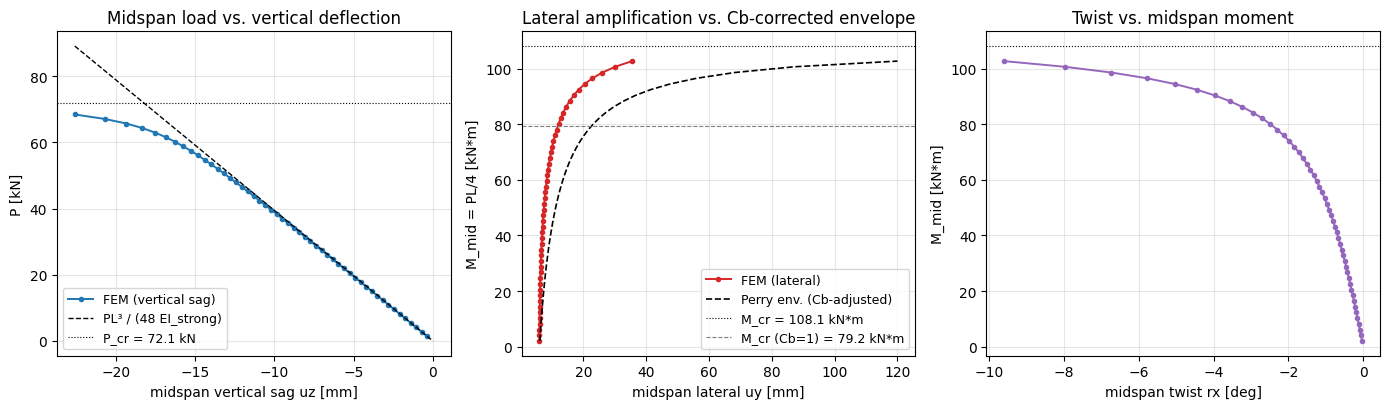

In [5]:
hist_P     = np.asarray(hist_P)
hist_M     = np.asarray(hist_M)
hist_uy    = np.asarray(hist_uy)
hist_uz    = np.asarray(hist_uz)
hist_twist = np.asarray(hist_twist)

eta     = hist_M / M_cr_mid
valid   = eta < 0.99
uy_env  = delta_0 / (1.0 - eta[valid])

fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))

# (a) P vs vertical sag, with linear-elastic reference
ax = axes[0]
ax.plot(hist_uz, hist_P / 1e3, 'o-', lw=1.4, ms=3, color='tab:blue',
        label='FEM (vertical sag)')
# Linear theory for midspan sag of simply-supported beam with midspan load:
# uz_mid = PL^3 / (48 EI_strong). Plot the inverse.
uz_ref = np.linspace(hist_uz.min(), 0, 50)
P_ref  = np.abs(uz_ref) * 48 * E * I_strong / L ** 3
ax.plot(uz_ref, P_ref / 1e3, 'k--', lw=1.0,
        label='PL\u00b3 / (48 EI_strong)')
ax.axhline(P_cr / 1e3, color='k', lw=0.8, ls=':',
           label=f'P_cr = {P_cr/1e3:.1f} kN')
ax.set_xlabel('midspan vertical sag uz [mm]')
ax.set_ylabel('P [kN]')
ax.set_title('Midspan load vs. vertical deflection')
ax.grid(True, alpha=0.3)
ax.legend(loc='lower left', fontsize=9)

# (b) M_mid vs lateral amplification with Cb-adjusted Perry envelope
ax = axes[1]
ax.plot(delta_0 + hist_uy, hist_M / 1e6, 'o-', lw=1.4, ms=3,
        color='tab:red', label='FEM (lateral)')
ax.plot(uy_env, hist_M[valid] / 1e6, 'k--', lw=1.2,
        label='Perry env. (Cb-adjusted)')
ax.axhline(M_cr_mid / 1e6, color='k', lw=0.8, ls=':',
           label=f'M_cr = {M_cr_mid/1e6:.1f} kN*m')
ax.axhline(M_cr_uniform / 1e6, color='tab:gray', lw=0.8, ls='--',
           label=f'M_cr (Cb=1) = {M_cr_uniform/1e6:.1f} kN*m')
ax.set_xlabel('midspan lateral uy [mm]')
ax.set_ylabel('M_mid = PL/4 [kN*m]')
ax.set_title('Lateral amplification vs. Cb-corrected envelope')
ax.grid(True, alpha=0.3)
ax.legend(loc='lower right', fontsize=9)

# (c) M_mid vs twist
ax = axes[2]
ax.plot(np.degrees(hist_twist), hist_M / 1e6, 'o-', lw=1.4, ms=3,
        color='tab:purple')
ax.axhline(M_cr_mid / 1e6, color='k', lw=0.8, ls=':')
ax.set_xlabel('midspan twist rx [deg]')
ax.set_ylabel('M_mid [kN*m]')
ax.set_title('Twist vs. midspan moment')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Time-series viewer with twist contour

Exactly as in the uniform-moment companion notebook: push every load
step as a pseudo-time frame, store the twist angle in degrees as a
scalar contour field. Scrubbing through the time axis animates the
beam bowing sideways and rotating about its longitudinal axis — the
classical LTB kinematics.

In [6]:
steps = []
for P_i, d_step, t_step in zip(hist_P, disp_per_step, twist_per_step):
    u_mag = np.linalg.norm(d_step, axis=1)
    steps.append({
        'time': float(P_i),
        'point_data': {
            'Displacement': d_step,
            '|U|':          u_mag,
            'Uy':           d_step[:, 1],
            'Uz':           d_step[:, 2],
            'twist_deg':    np.degrees(t_step),
        },
    })

print(f'time-series steps: {len(steps)}')
print(f'time range       : {steps[0]["time"]/1e3:.2f} to '
      f'{steps[-1]["time"]/1e3:.2f} kN')

# --- LEGACY-API-MIGRATED ---
# Materialize ``steps`` into ``(T, N)`` arrays for ``NativeWriter``.
# Vector fields (shape ``(N, 3)``) split into per-axis scalar components.
_legacy_components = {}
for _legacy_cname, _legacy_cval0 in steps[0]["point_data"].items():
    _legacy_arr0 = np.asarray(_legacy_cval0)
    if _legacy_arr0.ndim == 2 and _legacy_arr0.shape[1] in (2, 3):
        for _legacy_i, _legacy_ax in enumerate(["x", "y", "z"][: _legacy_arr0.shape[1]]):
            _legacy_components[f"{_legacy_cname}_{_legacy_ax}"] = np.stack(
                [np.asarray(_s["point_data"][_legacy_cname])[:, _legacy_i]
                 for _s in steps], axis=0,
            )
    else:
        _legacy_components[_legacy_cname] = np.stack(
            [np.asarray(_s["point_data"][_legacy_cname]) for _s in steps],
            axis=0,
        )
_legacy_time = np.array([_s["time"] for _s in steps], dtype=float)
# Determine node count from the data, then pick node_ids that match.
_legacy_first = next(iter(steps[0]["point_data"].values()))
_legacy_N = int(np.asarray(_legacy_first).shape[0])
if ['pg_beam']:
    _legacy_node_ids = np.asarray(
        fem.nodes.get_ids(pg='pg_beam'), dtype=np.int64,
    )
    if _legacy_node_ids.size != _legacy_N:
        # Falls back to all nodes if the pg cardinality doesn't match
        # the per-step data (covers cases where the user collected
        # disp on a different subset than the legacy ``include_pgs``).
        _legacy_node_ids = np.asarray(fem.nodes.ids, dtype=np.int64)
else:
    _legacy_node_ids = np.asarray(fem.nodes.ids, dtype=np.int64)
if _legacy_node_ids.size != _legacy_N:
    raise RuntimeError(
        f"node_ids has {_legacy_node_ids.size} entries but step data "
        f"has {_legacy_N} — adjust the source of node_ids in this cell."
    )
from pathlib import Path as _LegacyPath
from apeGmsh.results.writers import NativeWriter as _LegacyNativeWriter
_legacy_path = _LegacyPath(f"{'LTB_midspan_load'}_legacy.h5")
if _legacy_path.exists():
    _legacy_path.unlink()
with _LegacyNativeWriter(_legacy_path) as _legacy_nw:
    _legacy_nw.open(fem=fem)
    _legacy_sid = _legacy_nw.begin_stage(name='LTB_midspan_load', kind="static", time=_legacy_time)
    _legacy_nw.write_nodes(
        _legacy_sid, "partition_0",
        node_ids=_legacy_node_ids, components=_legacy_components,
    )
    _legacy_nw.end_stage()
results = Results.from_native(_legacy_path, fem=fem)
results.viewer(blocking=False)

time-series steps: 50
time range       : 1.37 to 68.46 kN


<Popen: returncode: None args: ['C:\\Users\\nmora\\venv\\opensees_venv\\Scri...>

## 9. Capture results — manual + DomainCapture paths

Two ways to produce a native-HDF5 results file consumable by the
apeGmsh ``ResultsViewer``:

1. **Manual path** — query the live OpenSees domain post-analysis,
   open a ``NativeWriter``, and write nodal displacements yourself.
   Good for one-shot snapshots and post-hoc diagnostics.
2. **DomainCapture path** — declare what to capture with
   ``Recorders().nodes(...)``, hand the spec to a ``DomainCapture``
   context, and call ``cap.step(t=...)`` after each ``ops.analyze``
   (the helper does it for you). Scales to multi-stage, transient,
   modal, and multi-recorder runs.

Both produce a file that ``Results.from_native(path).viewer()`` can
open. The viewer launch is gated on ``APEGMSH_SKIP_VIEWER`` so this
notebook is safe to run under nbconvert / CI.


In [7]:
# --- EOS-WIRING-V1 ---
# Manual path: pull displacements off the live domain, write h5 yourself.
from pathlib import Path
import numpy as np
from apeGmsh.results.writers import NativeWriter

results_manual = Path("example_LTB_midspan_load_manual.h5")
if results_manual.exists():
    results_manual.unlink()

_n = len(fem.nodes.ids)
_ux = np.array([ops.nodeDisp(int(nid), 1) for nid in fem.nodes.ids])
_uy = np.array([ops.nodeDisp(int(nid), 2) for nid in fem.nodes.ids])
_uz = np.array([ops.nodeDisp(int(nid), 3) for nid in fem.nodes.ids])
_components = {
    "displacement_x": _ux.reshape(1, _n),
    "displacement_y": _uy.reshape(1, _n),
    "displacement_z": _uz.reshape(1, _n),
}

with NativeWriter(results_manual) as _nw:
    _nw.open(fem=fem)
    _sid = _nw.begin_stage(name="static", kind="static", time=np.array([1.0]))
    _nw.write_nodes(
        _sid, "partition_0",
        node_ids=np.asarray(fem.nodes.ids, dtype=np.int64),
        components=_components,
    )
    _nw.end_stage()

print(f"manual -> {results_manual} ({results_manual.stat().st_size/1024:.1f} KB)")


manual -> example_LTB_midspan_load_manual.h5 (52.2 KB)


In [8]:
# DomainCapture path: declarative recorders, capture during analyze.
from apeGmsh.solvers.Recorders import Recorders
from apeGmsh.results.capture._domain import DomainCapture

recs = Recorders()
recs.nodes(components="displacement")
recs.nodes(components="reaction_force")
spec = recs.resolve(fem, ndm=3, ndf=6)

results_capture = Path("example_LTB_midspan_load_capture.h5")
if results_capture.exists():
    results_capture.unlink()

with DomainCapture(spec, results_capture, fem, ndm=3, ndf=6) as cap:
    cap.begin_stage("run", kind="static")
    # --- copied from cell 5 ---
    import openseespy.opensees as ops

    ops.wipe()
    ops.model('basic', '-ndm', 3, '-ndf', 6)
    ops.timeSeries('Linear', 1)

    for nid, xyz in fem.nodes.get():
        ops.node(int(nid), float(xyz[0]), float(xyz[1]), float(xyz[2]))

    pin_id  = int(fem.nodes.get_ids(target='pin')[0])
    roll_id = int(fem.nodes.get_ids(target='roller')[0])
    ops.fix(pin_id,  1, 1, 1,  1, 0, 0)
    ops.fix(roll_id, 0, 1, 1,  1, 0, 0)

    ops.geomTransf('Corotational', 1, 0, 0, 1)

    n_elem = 0
    for group in fem.elements.get(element_type='line2'):
        for eid, conn in group:
            ops.element(
                'elasticBeamColumn', int(eid),
                int(conn[0]), int(conn[1]),
                A, E, G, J, I_strong, I_weak, 1,
            )
            n_elem += 1
    print(f'elasticBeamColumn elements: {n_elem}')

    # --- Locate midspan node for load application --------------------
    beam_ids    = np.array(
        [int(n) for n in fem.nodes.get_ids(target='pg_beam')])
    beam_coords = fem.nodes.get_coords(target='pg_beam')
    order       = np.argsort(beam_coords[:, 0])
    beam_ids    = beam_ids[order]
    beam_coords = beam_coords[order]
    xs          = beam_coords[:, 0]
    mid_idx     = int(np.argmin(np.abs(xs - L / 2.0)))
    mid_nid     = int(beam_ids[mid_idx])
    print(f'midspan node id = {mid_nid} at x = {xs[mid_idx]:.1f} mm')
    # --- copied from cell 7 ---
    ops.pattern('Plain', 1, 1)
    ops.load(mid_nid, 0, 0, -1.0, 0, 0, 0)     # -1 N in global Z at midspan

    ops.constraints('Transformation')
    ops.numberer('RCM')
    ops.system('UmfPack')
    ops.test('NormDispIncr', 1.0e-7, 200)
    ops.algorithm('Newton')

    P_target = 0.95 * P_cr
    n_steps  = 50
    dP       = P_target / n_steps
    ops.integrator('LoadControl', dP)
    ops.analysis('Static')

    hist_P       = []
    hist_M       = []          # = P*L/4 — midspan moment
    hist_uy      = []
    hist_uz      = []
    hist_twist   = []
    disp_per_step: list[np.ndarray] = []
    twist_per_step: list[np.ndarray] = []
    n_nodes = len(fem.nodes.ids)

    for step in range(n_steps):
        ok = ops.analyze(1)
        cap.step(t=ops.getTime())
        if ok != 0:
            print(f'analysis failed at step {step + 1}')
            break
        P_now = (step + 1) * dP
        M_mid = P_now * L / 4.0
        d = ops.nodeDisp(mid_nid)
        hist_P.append(P_now)
        hist_M.append(M_mid)
        hist_uy.append(d[1])
        hist_uz.append(d[2])
        hist_twist.append(d[3])

        d_full = np.zeros((n_nodes, 3), dtype=np.float64)
        t_full = np.zeros(n_nodes, dtype=np.float64)
        for i, nid in enumerate(fem.nodes.ids):
            di = ops.nodeDisp(int(nid))
            d_full[i, 0] = di[0]
            d_full[i, 1] = di[1]
            d_full[i, 2] = di[2]
            t_full[i]    = di[3]
        disp_per_step.append(d_full)
        twist_per_step.append(t_full)

    print(f'converged in {len(hist_P)} of {n_steps} steps')
    print(f'final P       = {hist_P[-1]/1e3:.3f} kN   '
          f'({hist_P[-1]/P_cr*100:.1f}% P_cr)')
    print(f'final M_mid   = {hist_M[-1]/1e6:.3f} kN*m '
          f'({hist_M[-1]/M_cr_mid*100:.1f}% M_cr_mid)')
    print(f'final uy mid  = {hist_uy[-1]:+.3f} mm   '
          f'(lateral amplification \u2248 '
          f'{(delta_0 + hist_uy[-1])/delta_0:.2f}x)')
    print(f'final uz mid  = {hist_uz[-1]:+.3f} mm   (vertical sag)')
    print(f'final twist   = {hist_twist[-1]:+.4e} rad  '
          f'({np.degrees(hist_twist[-1]):+.2f} deg)')
    cap.end_stage()

print(f"capture -> {results_capture} ({results_capture.stat().st_size/1024:.1f} KB)")


elasticBeamColumn elements: 48


midspan node id = 10 at x = 3000.0 mm


converged in 50 of 50 steps


final P       = 68.463 kN   (95.0% P_cr)
final M_mid   = 102.694 kN*m (95.0% M_cr_mid)
final uy mid  = +29.473 mm   (lateral amplification ≈ 5.91x)
final uz mid  = -22.607 mm   (vertical sag)
final twist   = -1.6760e-01 rad  (-9.60 deg)
capture -> example_LTB_midspan_load_capture.h5 (166.5 KB)


In [9]:
# Open the captured run in the apeGmsh ResultsViewer (subprocess,
# non-blocking). Set APEGMSH_SKIP_VIEWER=1 to skip in headless / CI.
import os
from apeGmsh.results import Results
results = Results.from_native(results_capture)
if os.environ.get("APEGMSH_SKIP_VIEWER"):
    print("[skip viewer] APEGMSH_SKIP_VIEWER set")
else:
    handle = results.viewer(blocking=False)
    print(f"viewer pid: {handle.pid}  -- close window to exit.")


[skip viewer] APEGMSH_SKIP_VIEWER set
